
# CryptoCast: Multi-Horizon Bitcoin Price Forecasting Using Deep Learning


## Step 1: Install Libraries

In [1]:
!pip install tensorflow pandas numpy matplotlib scikit-learn -q

## Step 2: Import Libraries

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, SimpleRNN, LSTM, Conv1D,
    MaxPooling1D, Flatten, Dropout,
    Input, LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D
)

from tensorflow.keras.callbacks import EarlyStopping


## Step 3: Load Dataset

In [3]:
df = pd.read_csv("/content/Bitcoin Historical Data.csv")
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,24-03-2024,"67,211.9","64,036.5","67,587.8","63,812.9",65.59K,4.96%
1,23-03-2024,"64,037.8","63,785.6","65,972.4","63,074.9",35.11K,0.40%
2,22-03-2024,"63,785.5","65,501.5","66,633.3","62,328.3",72.43K,-2.62%
3,21-03-2024,"65,503.8","67,860.0","68,161.7","64,616.1",75.26K,-3.46%
4,20-03-2024,"67,854.0","62,046.8","68,029.5","60,850.9",133.53K,9.35%


## Step 5: Data Preprocessing

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
display(df)

/tmp/ipykernel_7158/2813018634.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


,Date,Price,Open,High,Low,Vol.,Change %
0,2024-03-24,"67,211.9","64,036.5","67,587.8","63,812.9",65.59K,4.96%
1,2024-03-23,"64,037.8","63,785.6","65,972.4","63,074.9",35.11K,0.40%
2,2024-03-22,"63,785.5","65,501.5","66,633.3","62,328.3",72.43K,-2.62%
3,2024-03-21,"65,503.8","67,860.0","68,161.7","64,616.1",75.26K,-3.46%
4,2024-03-20,"67,854.0","62,046.8","68,029.5","60,850.9",133.53K,9.35%
...,...,...,...,...,...,...,...
4994,2010-07-22,0.1,0.1,0.1,0.1,2.16K,0.00%
4995,2010-07-21,0.1,0.1,0.1,0.1,0.58K,0.00%
4996,2010-07-20,0.1,0.1,0.1,0.1,0.26K,0.00%
4997,2010-07-19,0.1,0.1,0.1,0.1,0.57K,0.00%


In [7]:
df = df.sort_values('Date')

numeric_cols = ['Price', 'Open', 'High', 'Low']

for col in numeric_cols:
    df[col] = df[col].astype(str).str.replace(',', '')
    df[col] = pd.to_numeric(df[col], errors='coerce')

def convert_volume(x):

    x = str(x)

    if 'K' in x:
        return float(x.replace('K', '')) * 1000

    elif 'M' in x:
        return float(x.replace('M', '')) * 1000000

    elif 'B' in x:
        return float(x.replace('B', '')) * 1000000000

    return pd.to_numeric(x, errors='coerce')

df['Vol.'] = df['Vol.'].apply(convert_volume)

df['Change %'] = (
    df['Change %']
    .astype(str)
    .str.replace('%', '')
)

df['Change %'] = pd.to_numeric(df['Change %'], errors='coerce')
df.dropna(inplace=True)
display(df)


,Date,Price,Open,High,Low,Vol.,Change %
4998,2010-07-18,0.1,0.0,0.1,0.1,80.0,0.00
4997,2010-07-19,0.1,0.1,0.1,0.1,570.0,0.00
4996,2010-07-20,0.1,0.1,0.1,0.1,260.0,0.00
4995,2010-07-21,0.1,0.1,0.1,0.1,580.0,0.00
4994,2010-07-22,0.1,0.1,0.1,0.1,2160.0,0.00
...,...,...,...,...,...,...,...
4,2024-03-20,67854.0,62046.8,68029.5,60850.9,133530.0,9.35
3,2024-03-21,65503.8,67860.0,68161.7,64616.1,75260.0,-3.46
2,2024-03-22,63785.5,65501.5,66633.3,62328.3,72430.0,-2.62
1,2024-03-23,64037.8,63785.6,65972.4,63074.9,35110.0,0.40


## Step 4: Feature Scaling

In [9]:
features = ['Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']
data = df[features]
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)
scaled_data.shape

(4993, 6)

## Step 5: Create Sequences

In [10]:

SEQUENCE_LENGTH = 60

def create_sequences(data, target_index=0, horizon=1):

    X = []
    y = []

    for i in range(SEQUENCE_LENGTH, len(data)-horizon):

        X.append(data[i-SEQUENCE_LENGTH:i])

        y.append(data[i:i+horizon, target_index])

    return np.array(X), np.array(y)

X_1d, y_1d = create_sequences(scaled_data, horizon=1)

print(X_1d.shape)
print(y_1d.shape)


(4932, 60, 6)
(4932, 1)


## Step 6: Train Test Split

In [11]:

split = int(len(X_1d) * 0.8)

X_train = X_1d[:split]
X_test = X_1d[split:]

y_train = y_1d[:split]
y_test = y_1d[split:]

print(X_train.shape)
print(X_test.shape)


(3945, 60, 6)
(987, 60, 6)


## Step 7: CNN Model

In [12]:

def build_cnn_model(input_shape):

    model = Sequential([
        Conv1D(64, 3, activation='relu',
               input_shape=input_shape),

        MaxPooling1D(2),

        Dropout(0.2),

        Flatten(),

        Dense(64, activation='relu'),

        Dense(1)
    ])

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    return model

cnn_model = build_cnn_model(
    (X_train.shape[1], X_train.shape[2])
)

cnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1856)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       118,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,129 (469.25 KB)

 Trainable params: 120,129 (469.25 KB)

 Non-trainable params: 0 (0.00 B)

## Step 8: RNN Model

In [13]:

def build_rnn_model(input_shape):

    model = Sequential([
        SimpleRNN(64, input_shape=input_shape),

        Dropout(0.2),

        Dense(32, activation='relu'),

        Dense(1)
    ])

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    return model

rnn_model = build_rnn_model(
    (X_train.shape[1], X_train.shape[2])
)

rnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,657 (26.00 KB)

 Trainable params: 6,657 (26.00 KB)

 Non-trainable params: 0 (0.00 B)

## Step 9: LSTM Model

In [14]:

def build_lstm_model(input_shape):

    model = Sequential([
        LSTM(64,
             return_sequences=True,
             input_shape=input_shape),

        Dropout(0.2),

        LSTM(64),

        Dropout(0.2),

        Dense(32, activation='relu'),

        Dense(1)
    ])

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    return model

lstm_model = build_lstm_model(
    (X_train.shape[1], X_train.shape[2])
)

lstm_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,313 (208.25 KB)

 Trainable params: 53,313 (208.25 KB)

 Non-trainable params: 0 (0.00 B)

## Step 10: Transformer Model

In [15]:

def transformer_encoder(inputs,
                        head_size,
                        num_heads,
                        ff_dim,
                        dropout=0):

    x = LayerNormalization(epsilon=1e-6)(inputs)

    x = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(x, x)

    x = Dropout(dropout)(x)

    res = x + inputs

    x = LayerNormalization(epsilon=1e-6)(res)

    x = Dense(ff_dim, activation='relu')(x)

    x = Dropout(dropout)(x)

    x = Dense(inputs.shape[-1])(x)

    return x + res

def build_transformer_model(input_shape):

    inputs = Input(shape=input_shape)

    x = transformer_encoder(
        inputs,
        head_size=64,
        num_heads=4,
        ff_dim=64,
        dropout=0.2
    )

    x = GlobalAveragePooling1D()(x)

    x = Dense(64, activation='relu')(x)

    x = Dropout(0.2)(x)

    outputs = Dense(1)(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    return model

transformer_model = build_transformer_model(
    (X_train.shape[1], X_train.shape[2])
)

transformer_model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 60, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 60, 6)     │         12 │ input_layer_3[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 6)     │      6,918 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 60, 6)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 60, 6)     │          0 │ dropout_5[0][0],  │
│                     │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 6)     │         12 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 60, 64)    │        448 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 60, 64)    │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 60, 6)     │        390 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 60, 6)     │          0 │ dense_7[0][0],    │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 6)         │          0 │ add_1[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │        448 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64)        │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │         65 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,293 (32.39 KB)

 Trainable params: 8,293 (32.39 KB)

 Non-trainable params: 0 (0.00 B)

## Step 11: Train Models

In [16]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

EPOCHS = 20
BATCH_SIZE = 32


In [17]:

cnn_history = cnn_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop]
)


Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 1.8681e-04 - val_loss: 0.0099
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.1194e-05 - val_loss: 0.0060
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1258e-05 - val_loss: 0.0021
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.2363e-05 - val_loss: 9.3036e-04
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.8197e-05 - val_loss: 0.0027
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4.5356e-05 - val_loss: 0.0012
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.3061e-05 - val_loss: 0.0031
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4.3107e-05 - val_loss: 0.0013
Epoch 9/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.5404e-05 - val_loss: 0.0030


In [18]:

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop]
)


Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.0018 - val_loss: 0.0174
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.0865e-04 - val_loss: 0.0129
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.5532e-04 - val_loss: 0.0085
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.2379e-04 - val_loss: 0.0084
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.0425e-04 - val_loss: 0.0048


In [19]:

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop]
)


Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 1.5817e-04 - val_loss: 0.0066
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.8585e-05 - val_loss: 0.0048
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.5411e-05 - val_loss: 0.0032
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.0093e-05 - val_loss: 0.0018
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.5557e-05 - val_loss: 0.0018


In [20]:

transformer_history = transformer_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop]
)


Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - loss: 0.0021 - val_loss: 0.0721
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.0458e-04 - val_loss: 0.0736
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2328e-04 - val_loss: 0.0718
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.1667e-04 - val_loss: 0.0675
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.0434e-04 - val_loss: 0.0801


## Step 12: Evaluation

In [21]:

def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    mape = np.mean(
        np.abs((y_test - predictions) / y_test)
    ) * 100

    return mae, rmse, mape, predictions


In [22]:

cnn_mae, cnn_rmse, cnn_mape, cnn_pred = evaluate_model(
    cnn_model, X_test, y_test
)

rnn_mae, rnn_rmse, rnn_mape, rnn_pred = evaluate_model(
    rnn_model, X_test, y_test
)

lstm_mae, lstm_rmse, lstm_mape, lstm_pred = evaluate_model(
    lstm_model, X_test, y_test
)

transformer_mae, transformer_rmse, transformer_mape, transformer_pred = evaluate_model(
    transformer_model, X_test, y_test
)

results = pd.DataFrame({
    'Model': ['CNN', 'RNN', 'LSTM', 'Transformer'],
    'MAE': [cnn_mae, rnn_mae, lstm_mae, transformer_mae],
    'RMSE': [cnn_rmse, rnn_rmse, lstm_rmse, transformer_rmse],
    'MAPE': [cnn_mape, rnn_mape, lstm_mape, transformer_mape]
})

results


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


,Model,MAE,RMSE,MAPE
0,CNN,0.023971,0.034115,4.939285
1,RNN,0.140156,0.188045,24.588436
2,LSTM,0.083501,0.114252,14.698807
3,Transformer,0.321661,0.392678,59.965593


## Step 13: Prediction Visualization

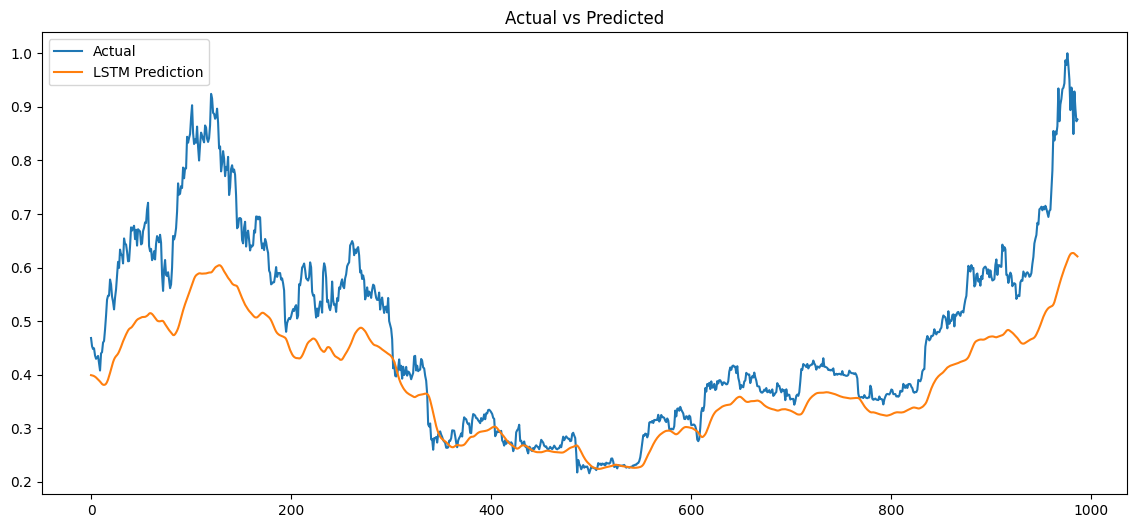

In [23]:

plt.figure(figsize=(14,6))

plt.plot(y_test, label='Actual')

plt.plot(lstm_pred, label='LSTM Prediction')

plt.legend()

plt.title("Actual vs Predicted")

plt.show()


## Step 14: Save Models

In [24]:

cnn_model.save("cnn_model.h5")
rnn_model.save("rnn_model.h5")
lstm_model.save("lstm_model.h5")
transformer_model.save("transformer_model.h5")

print("Models Saved")


Models Saved


## Step 15: Multi-Horizon Forecasting

In [25]:

def future_forecast(model, recent_data, horizon):

    predictions = []

    current_batch = recent_data.copy()

    for _ in range(horizon):

        pred = model.predict(
            current_batch.reshape(
                1,
                current_batch.shape[0],
                current_batch.shape[1]
            )
        )

        predictions.append(pred[0][0])

    return predictions

recent_data = scaled_data[-60:]

forecast_1d = future_forecast(lstm_model, recent_data, 1)

forecast_3d = future_forecast(lstm_model, recent_data, 3)

forecast_7d = future_forecast(lstm_model, recent_data, 7)

print("1 Day Forecast:", forecast_1d)
print("3 Day Forecast:", forecast_3d)
print("7 Day Forecast:", forecast_7d)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1 Day Forecast: [np.float32(0.6171806)]
3 Day Forecast: [np.float32(0.6171806), np.float32(0.6171806), np.float32(0.6171806)]
7 Day Forecast: [np.float32(0.6171806), np.float32(0.6171806), np.float32(0.6171806), np.float32(0.6171806), np.float32(0.6171806), np.float32(0.6171806), np.float32(0.6171806)]


In [26]:
print('Model Comparison:')
display(results)

best_model_row = results.loc[results['MAE'].idxmin()]
best_model_name = best_model_row['Model']

print(f"\nThe best performing model is the {best_model_name} model, with the lowest MAE, RMSE, and MAPE scores.")
print(f"The {best_model_name} model has already been saved as '{best_model_name.lower()}_model.h5' in a previous step.")

Model Comparison:


,Model,MAE,RMSE,MAPE
0,CNN,0.023971,0.034115,4.939285
1,RNN,0.140156,0.188045,24.588436
2,LSTM,0.083501,0.114252,14.698807
3,Transformer,0.321661,0.392678,59.965593



The best performing model is the CNN model, with the lowest MAE, RMSE, and MAPE scores.
The CNN model has already been saved as 'cnn_model.h5' in a previous step.
